# U-Net Segmentation
This notebook uses **U-Net** to segment tumors in BUSI breast ultrasound images. It covers data preparation, model training, evaluation using **Dice, IoU, and HD95**, and visualization of predicted tumor masks.

## Imports and Setup

Imports the libraries needed for this notebook: standard library utilities (`os`, `random`), array/dataframe handling (`numpy`, `pandas`), image I/O (`PIL.Image`), PyTorch and its data-loading utilities, torchvision transforms, and matplotlib for visualization.

In [1]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.utils.data
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

Fixes the random seed (42) across `random`, `numpy`, and `torch` for reproducibility, and defines the path and hyperparameter constants (dataset locations, image size, batch size) used throughout the rest of the notebook.

In [2]:
# --- Reproducibility: fix the seed for random, numpy, and torch ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# --- Path and hyperparameter constants ---
IMAGE_DIR = "/data/barbanp/datasets/BUSI/images-20260621T231610Z-3-001/images/"
MASK_DIR  = "/data/barbanp/datasets/BUSI/labels-20260621T231615Z-3-001/labels/"
TRAIN_CSV = "/data/barbanp/datasets/BUSI/train.xlsx"
TEST_CSV  = "/data/barbanp/datasets/BUSI/test.xlsx"
IMG_SIZE  = 256
BATCH_SIZE = 8

## Dataset and Dataloader

Defines `BUSISegmentationDataset`, a `torch.utils.data.Dataset` that reads image filenames from the `Image` column of the train/test `.xlsx` files (the `Label` classification column is ignored), pairs each filename with the identically-named mask file in `mask_dir`, and returns a normalized image tensor together with a binary mask tensor.

In [3]:
class BUSISegmentationDataset(torch.utils.data.Dataset):
    def __init__(self, xlsx_path, image_dir, mask_dir, transform=None):
        # Only the "Image" column (filenames) is used; "Label" is a classification label, not a mask path
        df = pd.read_excel(xlsx_path)
        self.filenames = df["Image"].tolist()
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform

        # ImageNet normalization statistics
        self.norm_mean = [0.485, 0.456, 0.406]
        self.norm_std = [0.229, 0.224, 0.225]

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        filename = self.filenames[idx]
        image_path = os.path.join(self.image_dir, filename)
        mask_path = os.path.join(self.mask_dir, filename)  # masks share the image's filename

        image = Image.open(image_path).convert("RGB")

        # BUSI masks are palette-indexed (mode "P") with foreground index 1, not 0-255 grayscale,
        # so re-encode as true grayscale before resizing/normalizing
        mask_raw = Image.open(mask_path)
        mask_arr = np.array(mask_raw)
        mask = Image.fromarray((mask_arr > 0).astype(np.uint8) * 255, mode="L")

        image = image.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        mask = mask.resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)  # nearest-neighbor preserves binary mask values

        # Normalize the image using ImageNet mean/std
        image = np.array(image, dtype=np.float32) / 255.0
        image = (image - self.norm_mean) / self.norm_std
        image_tensor = torch.from_numpy(image).permute(2, 0, 1).float()

        # Binarize the mask: values > 0.5 become 1.0, else 0.0
        mask = np.array(mask, dtype=np.float32) / 255.0
        mask = (mask > 0.5).astype(np.float32)
        mask_tensor = torch.from_numpy(mask).unsqueeze(0).float()

        if self.transform is not None:
            image_tensor, mask_tensor = self.transform(image_tensor, mask_tensor)

        return image_tensor, mask_tensor

Instantiates the training and test datasets from `train.xlsx` and `test.xlsx` respectively, both pointing at the same `IMAGE_DIR`/`MASK_DIR`.

In [4]:
train_dataset = BUSISegmentationDataset(
    xlsx_path=TRAIN_CSV,
    image_dir=IMAGE_DIR,
    mask_dir=MASK_DIR,
)

test_dataset = BUSISegmentationDataset(
    xlsx_path=TEST_CSV,
    image_dir=IMAGE_DIR,
    mask_dir=MASK_DIR,
)

Wraps the datasets in `DataLoader`s: the training loader shuffles each epoch, while the test loader keeps a fixed order for reproducible evaluation.

In [5]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
)

Pulls a single batch from `train_loader` to verify tensor shapes and value ranges, then unnormalizes and displays the first image in the batch alongside its mask to visually confirm the image/mask pairing is correct.

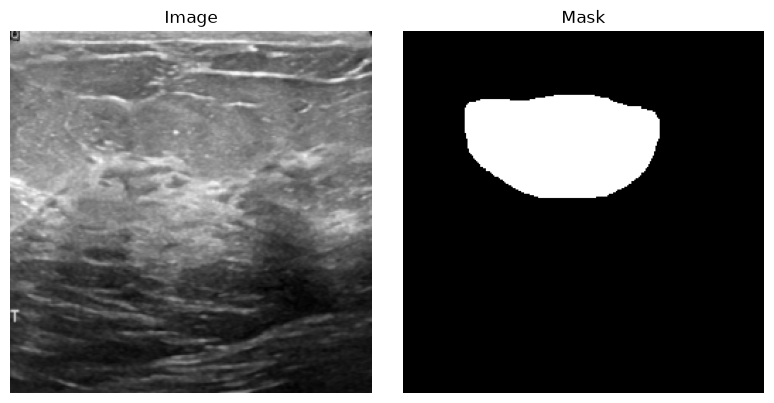

Image batch shape: torch.Size([8, 3, 256, 256])
Mask batch shape: torch.Size([8, 1, 256, 256])
Image min/max: -2.1179039478302 2.640000104904175
Mask unique values: tensor([0., 1.])


In [6]:
images, masks = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Mask batch shape:", masks.shape)
print("Image min/max:", images.min().item(), images.max().item())
print("Mask unique values:", torch.unique(masks))

# Unnormalize the first image for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
img_display = images[0] * std + mean
img_display = img_display.permute(1, 2, 0).clamp(0, 1).numpy()

mask_display = masks[0, 0].numpy()

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_display)
axes[0].set_title("Image")
axes[0].axis("off")
axes[1].imshow(mask_display, cmap="gray")
axes[1].set_title("Mask")
axes[1].axis("off")
plt.tight_layout()
plt.show()

### Double Convolution Block

Defines the convolution block used throughout the U-Net model to extract image features.

In [7]:
import torch.nn as nn


def double_conv(in_ch, out_ch):
    # Two 3x3 convs (padding=1) is the standard U-Net block; padding=1 keeps spatial size unchanged
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
    )

### UNet Model

Defines the full U-Net architecture (encoder, bottleneck, decoder, skip connections) using `double_conv` blocks.

In [8]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()

        # Encoder
        self.enc1 = double_conv(in_channels, 64)
        self.enc2 = double_conv(64, 128)
        self.enc3 = double_conv(128, 256)
        self.enc4 = double_conv(256, 512)
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = double_conv(512, 1024)

        # Decoder
        self.up4 = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = double_conv(1024, 512)  # concatenated with enc4 skip

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = double_conv(512, 256)   # concatenated with enc3 skip

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = double_conv(256, 128)   # concatenated with enc2 skip

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = double_conv(128, 64)    # concatenated with enc1 skip

        # Final 1x1 conv maps to a single-channel mask
        self.final = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        # Upsample, then concatenate the matching encoder skip connection
        d4 = self.up4(b)
        d4 = self.dec4(torch.cat([d4, e4], dim=1))

        d3 = self.up3(d4)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.final(d1)

### Forward-Pass Check

Instantiates the model, moves it to the available device, and runs a forward pass on one batch to verify the output shape.

In [9]:
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)

images, masks = next(iter(train_loader))
images, masks = images.to(device), masks.to(device)

# No grad needed; this is just a shape check, not training
with torch.no_grad():
    output = model(images)

print(f"Device:        {device}")
print(f"Input shape:   {images.shape}")
print(f"Output shape:  {output.shape}")
print(f"Mask shape:    {masks.shape}")

Device:        cuda:3
Input shape:   torch.Size([8, 3, 256, 256])
Output shape:  torch.Size([8, 1, 256, 256])
Mask shape:    torch.Size([8, 1, 256, 256])


### Loss Function

Combines **BCE loss** (per-pixel confidence) with **Dice loss** (region overlap) so training gets a useful signal even though the tumor covers only a small part of the image.

In [10]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        # Convert raw logits to probabilities in [0, 1] before computing overlap
        pred = torch.sigmoid(pred)
        intersection = (pred * target).sum()
        # smooth avoids a divide-by-zero when both prediction and target are all-background
        dice = (2 * intersection + self.smooth) / (pred.sum() + target.sum() + self.smooth)
        return 1 - dice


def bce_dice_loss(pred, target):
    # BCEWithLogitsLoss expects raw logits and applies sigmoid internally (more numerically
    # stable than a separate sigmoid + BCELoss), matching DiceLoss's own internal sigmoid
    return nn.BCEWithLogitsLoss()(pred, target) + DiceLoss()(pred, target)


criterion = bce_dice_loss

# lr controls the step size of each optimizer update; too high overshoots, too low trains slowly
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

### Training Loop

Each epoch runs a training pass over `train_loader`: a forward pass computes the loss, and **backpropagation** (`loss.backward()`) works backward through the network to figure out how much each weight contributed to that loss, which `optimizer.step()` then uses to update the weights. A validation pass over `test_loader` follows with weight updates disabled, so we can measure how well the model generalizes to unseen data without letting that data influence training.

In [11]:
NUM_EPOCHS = 50

for epoch in range(NUM_EPOCHS):
    # --- Training pass ---
    model.train()  # tells layers like BatchNorm to use training-time behavior
    train_loss = 0.0
    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()  # clear gradients from the previous batch so they don't accumulate
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()  # backpropagation: computes each weight's gradient w.r.t. the loss
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # --- Validation pass ---
    model.eval()  # tells layers like BatchNorm to use inference-time behavior
    val_loss = 0.0
    with torch.no_grad():  # no gradients needed since we are not updating weights here
        for images, masks in test_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(test_loader)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")

Epoch 1/50 - Train Loss: 1.3079 - Val Loss: 1.1648
Epoch 2/50 - Train Loss: 1.0946 - Val Loss: 1.3239
Epoch 3/50 - Train Loss: 1.0210 - Val Loss: 0.9892
Epoch 4/50 - Train Loss: 0.9304 - Val Loss: 0.9224
Epoch 5/50 - Train Loss: 0.8880 - Val Loss: 0.8398
Epoch 6/50 - Train Loss: 0.8262 - Val Loss: 0.8862
Epoch 7/50 - Train Loss: 0.8030 - Val Loss: 0.7393
Epoch 8/50 - Train Loss: 0.7630 - Val Loss: 0.7624
Epoch 9/50 - Train Loss: 0.7235 - Val Loss: 0.6905
Epoch 10/50 - Train Loss: 0.6788 - Val Loss: 0.7190
Epoch 11/50 - Train Loss: 0.6449 - Val Loss: 0.6838
Epoch 12/50 - Train Loss: 0.6101 - Val Loss: 1.1493
Epoch 13/50 - Train Loss: 0.5710 - Val Loss: 0.6094
Epoch 14/50 - Train Loss: 0.5540 - Val Loss: 0.5981
Epoch 15/50 - Train Loss: 0.5162 - Val Loss: 0.5245
Epoch 16/50 - Train Loss: 0.5029 - Val Loss: 0.5608
Epoch 17/50 - Train Loss: 0.4928 - Val Loss: 0.5399
Epoch 18/50 - Train Loss: 0.4501 - Val Loss: 0.5460
Epoch 19/50 - Train Loss: 0.4006 - Val Loss: 0.5226
Epoch 20/50 - Train L

## 5. Evaluation (Dice, IoU, HD95)

### Save Model Weights

Creates the `models/unet/` directory if needed and saves the trained model's weights to `unet_weights.pth`.

In [12]:
MODEL_DIR = "/data/barbanp/research_training/models/unet/"
os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_SAVE_PATH = os.path.join(MODEL_DIR, "unet_weights.pth")

# state_dict() holds only the learned parameters (conv/batchnorm weights and biases), not
# the model architecture itself, so UNet() must be reconstructed before loading these weights
torch.save(model.state_dict(), MODEL_SAVE_PATH)

print(f"Model weights saved to: {MODEL_SAVE_PATH}")

Model weights saved to: /data/barbanp/research_training/models/unet/unet_weights.pth


## 6. Visualization of Test Results